# GPT3-to-Plan vs NL2P-1

This figure compares GPT3-to-Plan and NL2P-1 across action F1 and argument F1. GPT3-to-Plan is plotted on the left and NL2P-1 on the right. The argument row also shows NL2P-1 adjusted argument F1 behind the unadjusted NL2P-1 bar.

In [34]:
import sys
from pathlib import Path

search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (path for path in search_roots if (path / "src/eval/read_eval.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Start Jupyter inside the llm-action-extraction repository.")
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

BASELINES = [
    ["win2k", "cEASDRL", 0.9275, 0.925],
    ["cooking", "cEASDRL", 0.852, 0.765],
    ["wikihow", "cEASDRL", 0.7843, 0.771],
    ["win2k", "cEASDRL*", 0.8393, 0.8008],
    ["cooking", "cEASDRL*", 0.7883, 0.665],
    ["wikihow", "cEASDRL*", 0.7174, 0.686],
]

local_method_labels = {
      "gpt3_to_plan": "GPT3-to-plan",
      "nl2p_1": METHOD_LABELS["nl2p_1"],
}

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=local_method_labels,
    model_order=MODEL_ORDER,
)

baseline_df = pd.DataFrame(
    BASELINES,
    columns=["domain", "method", "Action F1", "Argument F1"],
)

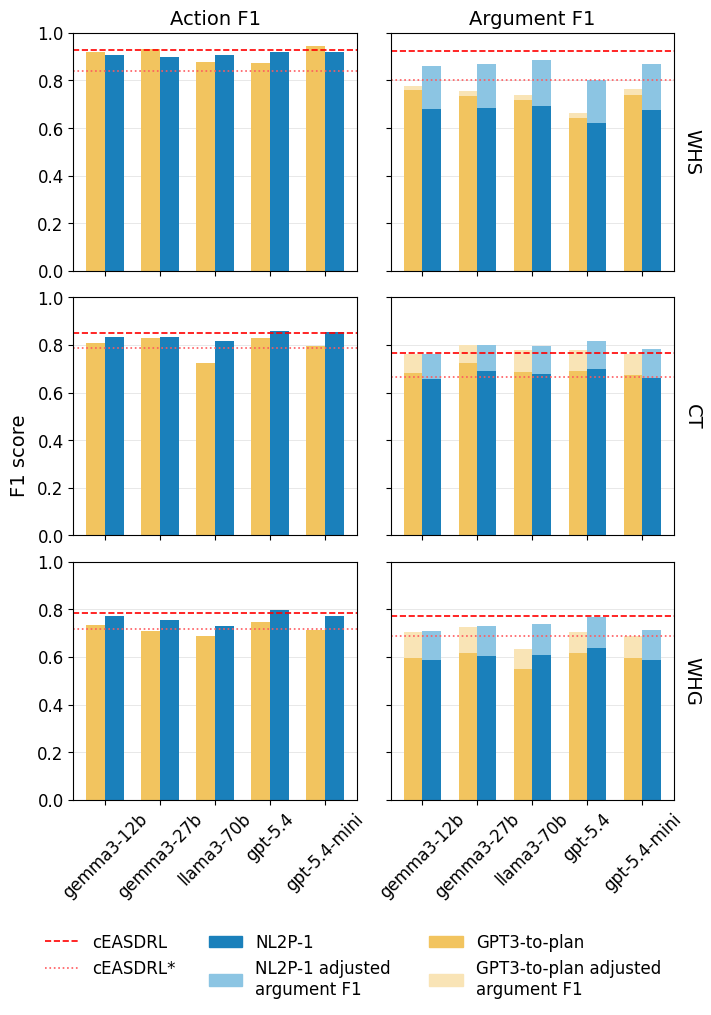

In [39]:
methods = ["gpt3_to_plan", "nl2p_1"]
method_colors = {
    "gpt3_to_plan": "#f2c45f",
    "nl2p_1": "#1a80bb",
}
adjusted_colors = {
    "gpt3_to_plan": "#f9e4b6",
    "nl2p_1": "#8cc5e3",
}
baseline_styles = {
    "cEASDRL": {"color": "red", "linestyle": "--", "linewidth": 1.2},
    "cEASDRL*": {"color": "#ff5a5e", "linestyle": "dotted", "linewidth": 1.2},
}
metrics = ["Action F1", "Argument F1"]
models = [model for model in MODEL_ORDER if model in set(result_df["model"].astype(str))]
model_labels = [local_method_labels.get(model, model) for model in models]

# --- Font Size Configuration ---
TITLE_SIZE = 14
LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

fig, axes = plt.subplots(
    nrows=len(DOMAIN_ORDER),
    ncols=len(metrics),
    figsize=(7.0, 9.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

fig.supylabel("F1 score", fontsize=LABEL_SIZE)

x = np.arange(len(models))
width = 0.34
offsets = {
    "gpt3_to_plan": -width / 2,
    "nl2p_1": width / 2,
}

for row_idx, domain in enumerate(DOMAIN_ORDER):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        panel = result_df[result_df["domain"] == domain]

        for method_key in methods:
            values = []
            adjusted_values = []
            for model in models:
                row = panel[
                    (panel["method"] == method_key)
                    & (panel["model"] == model)
                ]
                values.append(np.nan if row.empty else float(row.iloc[0][metric]))
                adjusted_values.append(
                    np.nan if row.empty or "Adjusted Argument F1" not in row.columns or pd.isna(row.iloc[0]["Adjusted Argument F1"]) else float(row.iloc[0]["Adjusted Argument F1"])
                )

            ax.bar(
                x + offsets[method_key],
                values,
                width=width,
                color=method_colors[method_key],
                edgecolor="none",
                label=local_method_labels[method_key],
                zorder=2,
            )

            if metric == "Argument F1" and any(pd.notna(v) for v in adjusted_values):
                delta_values = [
                    (adj - val) if (pd.notna(adj) and pd.notna(val)) else np.nan
                    for adj, val in zip(adjusted_values, values)
                ]
                ax.bar(
                    x + offsets[method_key],
                    delta_values,
                    bottom=values,
                    width=width,
                    color=adjusted_colors[method_key],
                    edgecolor="none",
                    label=f"{local_method_labels[method_key]} adjusted argument F1",
                    zorder=2,
                )

        baseline_panel = baseline_df[baseline_df["domain"] == domain]
        for baseline_name, style in baseline_styles.items():
            row = baseline_panel[baseline_panel["method"] == baseline_name]
            if not row.empty:
                ax.axhline(float(row.iloc[0][metric]), **style)

        if row_idx == 0:
            ax.set_title(metric, fontsize=TITLE_SIZE)

        if col_idx == len(metrics) - 1:
            ax.set_ylabel(DOMAIN_LABELS[domain], rotation=-90, labelpad=20, fontsize=TITLE_SIZE)
            ax.yaxis.set_label_position("right")

        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(x)
        if row_idx == len(DOMAIN_ORDER) - 1:
            ax.set_xticklabels(model_labels, rotation=45, fontsize=TICK_LABEL_SIZE)
            
        ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
        ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)

legend_handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=1.2, label="cEASDRL"),
    plt.Line2D([0], [0], color="#ff5a5e", linestyle="dotted", linewidth=1.2, label="cEASDRL*"),
    plt.Rectangle((0, 0), 1, 1, color=method_colors["nl2p_1"], label=local_method_labels["nl2p_1"]),
    plt.Rectangle((0, 0), 1, 1, color=adjusted_colors["nl2p_1"], label="NL2P-1 adjusted \nargument F1"),
    plt.Rectangle((0, 0), 1, 1, color=method_colors["gpt3_to_plan"], label=local_method_labels["gpt3_to_plan"]),
    plt.Rectangle((0, 0), 1, 1, color=adjusted_colors["gpt3_to_plan"], label="GPT3-to-plan adjusted \nargument F1"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
)
plt.show()
